💾 Generating Robustness Report (Including 128K)...
Starting BBPE Training for target size: 8000...
✅ Saved: ../reports/robustness_metrics.csv and robustness_chart.png


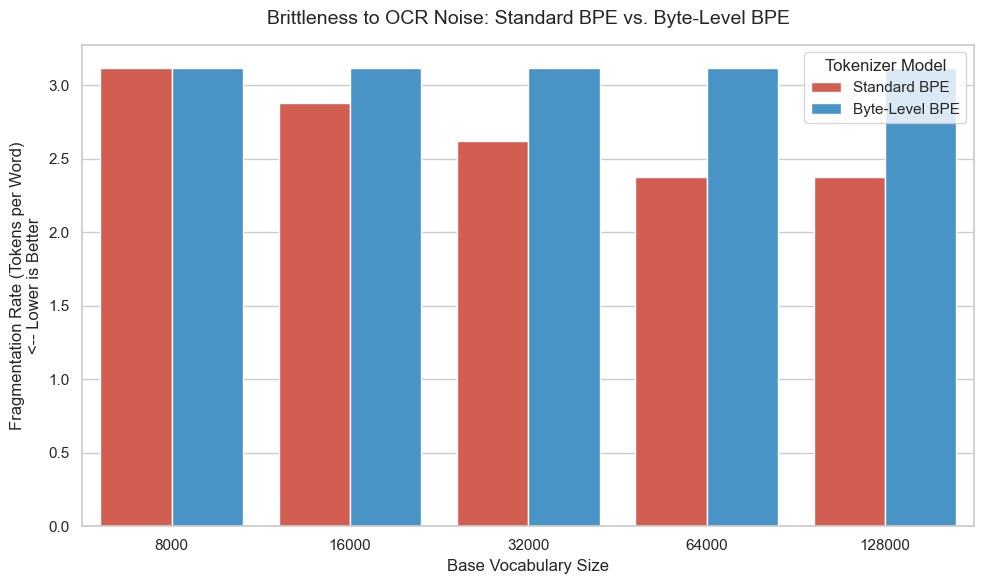

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append(os.path.abspath('../src'))
from bpe import BPETokenizer
from bbpe import BBPETokenizer
from noise import NoiseInjector

print("💾 Generating Robustness Report (Including 128K)...")
os.makedirs('../reports', exist_ok=True)

clean_text = "The artificial intelligence algorithm processed the documents perfectly."
injector = NoiseInjector(seed=42)
ocr_text = injector.inject_ocr_distortion(clean_text, error_rate=0.3)
word_count = len(clean_text.split())


with open('../data/raw/wikitext_sample.txt', 'r', encoding='utf-8') as f:
    bbpe_text = f.read()[:500000]
bbpe = BBPETokenizer()
bbpe.train(bbpe_text, target_vocab_size=8000)

target_sizes = [8000, 16000, 32000, 64000, 128000]
robust_metrics = []

for size in target_sizes:
    std_bpe = BPETokenizer()
    std_bpe.load(f'../vocabs/bpe_{size}.json')
    
    std_tokens = std_bpe.encode(ocr_text)['tokens']
    robust_metrics.append({
        "Vocabulary Size": size,
        "Tokenizer": "Standard BPE",
        "Tokens per Word (OCR Noise)": round(len(std_tokens) / word_count, 2)
    })
    
    bbpe_tokens = bbpe.encode(ocr_text)['tokens']
    robust_metrics.append({
        "Vocabulary Size": size,
        "Tokenizer": "Byte-Level BPE",
        "Tokens per Word (OCR Noise)": round(len(bbpe_tokens) / word_count, 2)
    })

df_robust = pd.DataFrame(robust_metrics)
df_robust.to_csv('../reports/robustness_metrics.csv', index=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=df_robust, x="Vocabulary Size", y="Tokens per Word (OCR Noise)", hue="Tokenizer", palette=["#e74c3c", "#3498db"])

plt.title("Brittleness to OCR Noise: Standard BPE vs. Byte-Level BPE", fontsize=14, pad=15)
plt.ylabel("Fragmentation Rate (Tokens per Word)\n<-- Lower is Better", fontsize=12)
plt.xlabel("Base Vocabulary Size", fontsize=12)
plt.legend(title="Tokenizer Model")

plt.tight_layout()
plt.savefig('../reports/robustness_chart.png', dpi=300)
print("✅ Saved: ../reports/robustness_metrics.csv and robustness_chart.png")
plt.show()